
**NOTE** - run in Colab  
Restart session if issue similar to "no laspy backend"

# 2D mapping of LiDAR data
Takes a 10X10X10 chunk, steps back 20m for each face and records the 6 faces as 2d images. This is repeated by moving over `stride` meters in the xyz directions.  
  
If there are two sequential lidar images you can concatenate edge points to retrieve the shared pixels that are cut off in the last boundary box.  
  
For a single laz file with 15 million points:  
* 5m stride takes 2 minutes to run
* 2m stride needs additional consideration with efficient RAM use by saving files midway.

In [10]:
!pip install laspy[lazrs,laszip]

In [11]:
import laspy
import numpy as np
from scipy.spatial import cKDTree

def generate_6_views(laz_path, window_size=10.0, stride=5.0, resolution=0.1, camera_setback=20.0):
    # 1. Load the point cloud
    las = laspy.read(laz_path)
    points = np.vstack((las.x, las.y, las.z)).T

    # 2. Build spatial index
    print("Building KDTree...")
    tree = cKDTree(points)

    mins = points.min(axis=0)
    maxs = points.max(axis=0)

    x_anchors = np.arange(mins[0], maxs[0], stride)
    y_anchors = np.arange(mins[1], maxs[1], stride)
    z_anchors = np.arange(mins[2], maxs[2], stride)

    xx, yy, zz = np.meshgrid(x_anchors, y_anchors, z_anchors, indexing='ij')
    centers = np.vstack([xx.ravel(), yy.ravel(), zz.ravel()]).T + (window_size / 2)

    print("Querying spatial grid...")
    cubes_indices = tree.query_ball_point(centers, r=window_size/2, p=np.inf)

    pixels_per_dim = int(window_size / resolution)
    snapshots = []

    print("Generating 2D projections...")
    for center, indices in zip(centers, cubes_indices):
        if len(indices) == 0:
            continue

        cube_pts = points[indices]

        corner = center - (window_size / 2)
        local_pts = cube_pts - corner

        coords = np.clip(np.floor(local_pts / resolution).astype(int), 0, pixels_per_dim - 1)
        cx, cy, cz = coords[:, 0], coords[:, 1], coords[:, 2]

        sort_x_asc, sort_x_desc = np.argsort(local_pts[:, 0]), np.argsort(local_pts[:, 0])[::-1]
        sort_y_asc, sort_y_desc = np.argsort(local_pts[:, 1]), np.argsort(local_pts[:, 1])[::-1]
        sort_z_asc, sort_z_desc = np.argsort(local_pts[:, 2]), np.argsort(local_pts[:, 2])[::-1]

        img_shape = (pixels_per_dim, pixels_per_dim)
        top, bottom = np.zeros(img_shape), np.zeros(img_shape)
        front, back = np.zeros(img_shape), np.zeros(img_shape)
        right, left = np.zeros(img_shape), np.zeros(img_shape)

        # 3. Project depths from the offset camera planes

        # --- Z-Axis Views (Camera moved 20m Up / Down) ---
        # Top (Looking down): Depth = Camera Z - Point Z
        top[cx[sort_z_asc], cy[sort_z_asc]] = (window_size + camera_setback) - local_pts[sort_z_asc, 2]
        # Bottom (Looking up): Depth = Point Z - Camera Z (which is negative setback)
        bottom[cx[sort_z_desc], cy[sort_z_desc]] = local_pts[sort_z_desc, 2] + camera_setback

        # --- Y-Axis Views (Camera moved 20m Back / Forward) ---
        # Front (Looking -Y): Depth = Camera Y - Point Y
        front[cx[sort_y_asc], cz[sort_y_asc]] = (window_size + camera_setback) - local_pts[sort_y_asc, 1]
        # Back (Looking +Y): Depth = Point Y - Camera Y
        back[cx[sort_y_desc], cz[sort_y_desc]] = local_pts[sort_y_desc, 1] + camera_setback

        # --- X-Axis Views (Camera moved 20m Right / Left) ---
        # Right (Looking -X): Depth = Camera X - Point X
        right[cy[sort_x_asc], cz[sort_x_asc]] = (window_size + camera_setback) - local_pts[sort_x_asc, 0]
        # Left (Looking +X): Depth = Point X - Camera X
        left[cy[sort_x_desc], cz[sort_x_desc]] = local_pts[sort_x_desc, 0] + camera_setback

        snapshot_tensor = np.stack([top, bottom, front, back, right, left])
        snapshots.append({
            'center': center,
            'features': snapshot_tensor
        })

    return snapshots

# Usage Example:
res = generate_6_views(
    'lid_0.laz',
    # context_window=30.0,
    # z_height = 40.0,
    stride=5.0,
    # resolution=0.1,
    camera_setback=150.0,
)

Building KDTree...
Querying spatial grid...
Generating 2D projections...


In [12]:
res[0]

{'center': array([6.58241260e+05, 4.08788413e+06, 8.52610000e+02]),
 'features': array([[[  0.  ,   0.  ,   0.  , ...,   0.  ,   0.  ,   0.  ],
         [  0.  ,   0.  ,   0.  , ...,   0.  ,   0.  ,   0.  ],
         [  0.  ,   0.  ,   0.  , ...,   0.  ,   0.  ,   0.  ],
         ...,
         [  0.  ,   0.  ,   0.  , ..., 152.42,   0.  ,   0.  ],
         [  0.  ,   0.  ,   0.  , ...,   0.  ,   0.  , 152.45],
         [  0.  ,   0.  ,   0.  , ...,   0.  ,   0.  ,   0.  ]],
 
        [[  0.  ,   0.  ,   0.  , ...,   0.  ,   0.  ,   0.  ],
         [  0.  ,   0.  ,   0.  , ...,   0.  ,   0.  ,   0.  ],
         [  0.  ,   0.  ,   0.  , ...,   0.  ,   0.  ,   0.  ],
         ...,
         [  0.  ,   0.  ,   0.  , ..., 157.58,   0.  ,   0.  ],
         [  0.  ,   0.  ,   0.  , ...,   0.  ,   0.  , 157.55],
         [  0.  ,   0.  ,   0.  , ...,   0.  ,   0.  ,   0.  ]],
 
        [[  0.  ,   0.  ,   0.  , ...,   0.  ,   0.  ,   0.  ],
         [  0.  ,   0.  ,   0.  , ...,   0.  ,   0.  ,

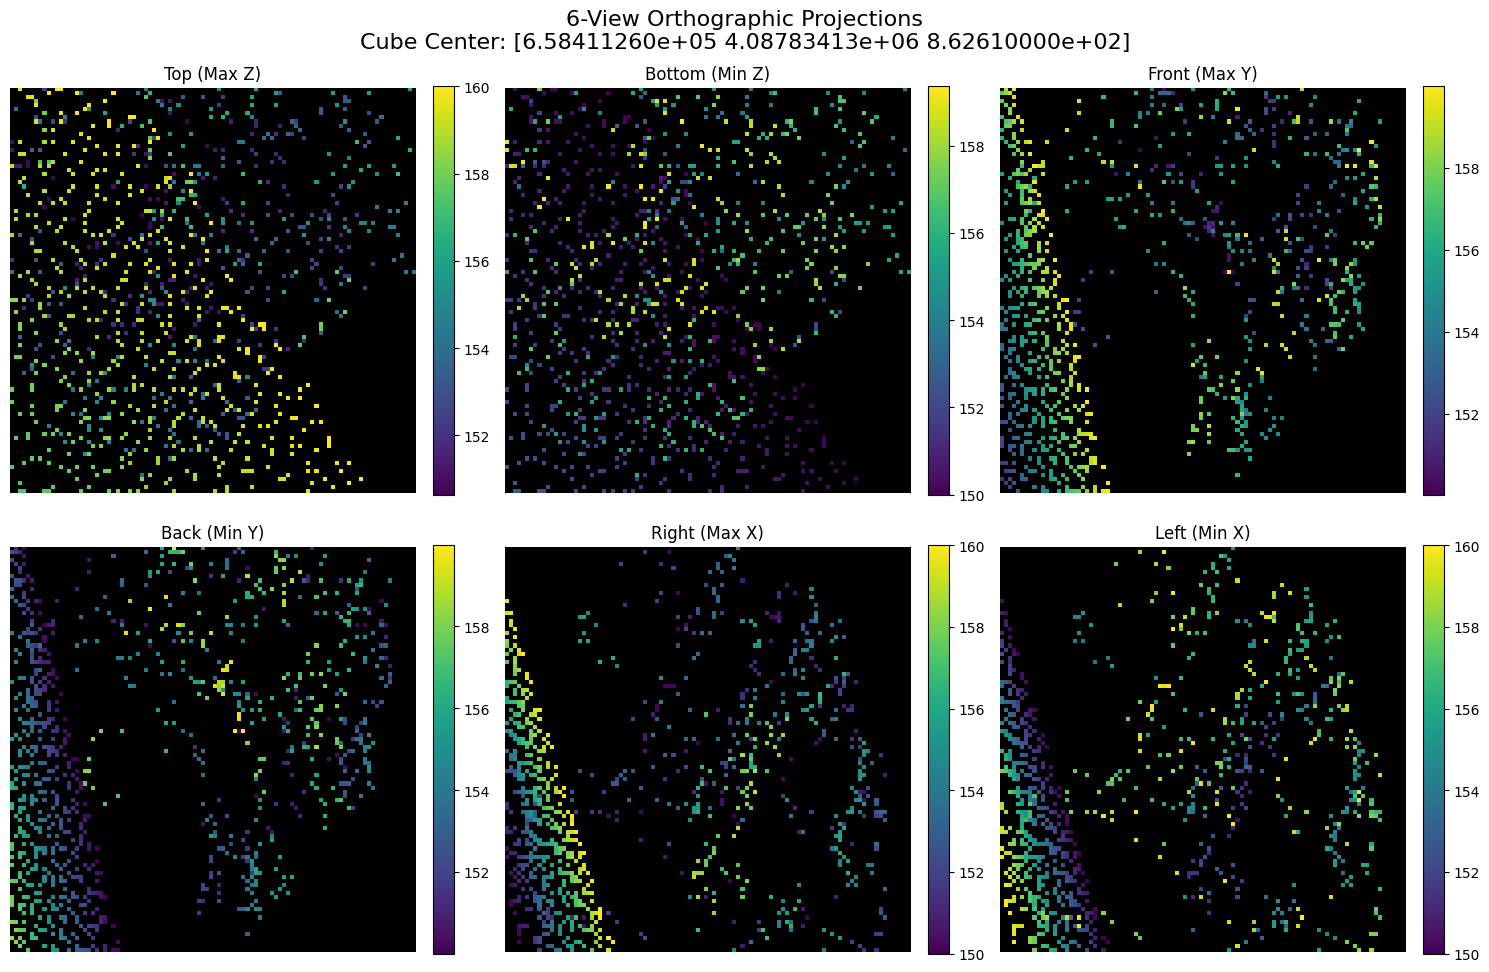

In [20]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_cube_faces(snapshot):
    """
    Visualizes the 6 orthographic projections from a single LiDAR snapshot.
    Expects a dictionary with 'features' (6, H, W) and 'center' (3,).
    """
    features = snapshot['features']
    center = snapshot['center']

    # Titles corresponding to the exact stack order in the generation script
    titles = [
        'Top (Max Z)', 'Bottom (Min Z)',
        'Front (Max Y)', 'Back (Min Y)',
        'Right (Max X)', 'Left (Min X)'
    ]

    # Set up a 2x3 grid for the 6 views
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(f'6-View Orthographic Projections\nCube Center: {center}', fontsize=16)

    for i, ax in enumerate(axes.flat):
        img = features[i]

        # Mask the 0s (empty space) so they don't impact the colormap scaling
        masked_img = np.ma.masked_where(img == 0, img)

        # Use a colormap that highlights depth/density, setting background to black
        cmap = plt.cm.viridis
        cmap.set_bad(color='black')

        # Display the image. 'origin=lower' matches the spatial coordinate system.
        im = ax.imshow(masked_img, cmap=cmap, origin='lower')

        ax.set_title(titles[i])
        ax.axis('off') # Hide axes ticks for cleaner image feature viewing

        # Add a colorbar to show the coordinate scale for each specific face
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

# Usage Example:
# Assuming 'result' is the list returned by generate_6_views()
visualize_cube_faces(res[5219]) # index 5219 shows a bush next to a tree trunk